#### 선형회귀와 경사하강법의 학습방법
모델의 최적화된 방법을 찾도록 도움을 주는 것
기울기(가중치)와 절편을 이용해 최적화된 모델을 찾아 주는 것 --> 경사하강법 
+ 선형회귀
SGD(Stochastic Gradient Descent)가 가중치와 절편을 이용해 오차(절대값, 제곱의 제곱근)를 줄여야 정답에 가까워짐.
경사하강법을 사용하지 않는다면 모든 경우의 수를 다 찾아야 한다.

##### 선형회귀식의 가중치(w)와 절편(bias) => Y = wX + b
머신러닝/딥러닝의 학습이란?
: 데이터를 계속 업데이트 하면서 모델에 적용시키면서 오차가 가장 적은 기준(Y와 Y^ 비교)으로 가중치와 절편을 찾는 것.

규칙이란?
: 가중치와 절편을 계속 업데이트 하는 것

규제란?
: 과대적합(train데이터는 정확도가 높으나 test데이터는 정확도가 낮음)을 방지하기 위해 가중치와 절편을 줄임
// 과소적합(test 데이터의 정확도는 높으나 train 데이터는 정확도가 낮음).

----

#### 당뇨병 환자 데이터

In [1]:
from sklearn.datasets import load_diabetes

In [2]:
diabetes = load_diabetes()

In [3]:
# 데이터의 크기 확인하기
print(diabetes.data.shape) # Feature
print(diabetes.target.shape) # Target


(442, 10)
(442,)


In [4]:
diabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [5]:
# data의 일부보기 (0~2번 Sample)
diabetes.data[0:2+1]

array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
        -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, -0.02632753, -0.00844872,
        -0.01916334,  0.07441156, -0.03949338, -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, -0.00567042, -0.04559945,
        -0.03419447, -0.03235593, -0.00259226,  0.00286131, -0.02593034]])

In [6]:
# target의 일부 보기(0~2번 Sample)
diabetes.target[:2+1]

array([151.,  75., 141.])

#### 당뇨병 환자 데이터의 시각화

In [7]:
import matplotlib.pyplot as plt

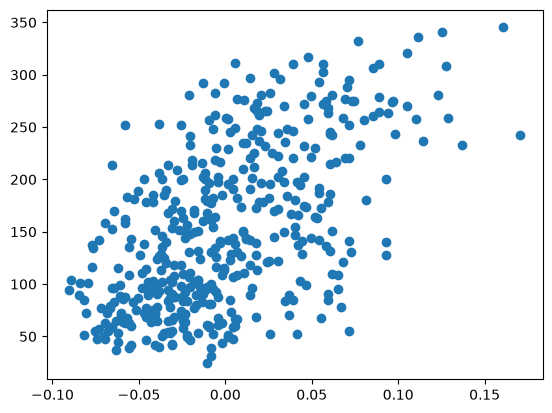

In [8]:
plt.scatter(
   diabetes.data[:,2], # x축
   diabetes.target # y축
)
plt.show()

In [9]:
# 상관계수 알아보기
import numpy as np

In [10]:
np.corrcoef(diabetes.data[:,2], diabetes.target)

array([[1.        , 0.58645013],
       [0.58645013, 1.        ]])

----
#### 경사하강법
: 경사하강법은 모델이 데이터를 잘 표현할 수 있도록 기울기(변화율)를 사용하여 모델을 조금씩 조정하는 최적화 알고리즘

##### 예측값과 변화율
변화율 = 0 : 최적화된 모델(Y(정답) - Y^(예측값) = 0) => 변화율(기울기) = 0

##### 예측값(Y^)
예측값은 하나의 모델에서 수식의 결과로 나온 값을 의미
예측값이 정답값으로 수렴해야 한다.

----

#### 훈련데이터에서 잘 맞는 w와 b를 찾는 방법 (Y = wX + b)
1. 무작위로 w와 b를 정한다.
2. X에서 샘플 하나를 선택하여 Y^을 계산한다.
3. Y^과 선택한 샘플의 진짜 Y를 비교한다. (예측값과 정답구하기 : 오차 구하기)
4. Y^이 Y와 가까워지도록 w,b를 조정한다. (모댈 조정하기 : 학습하기)
5. 모든 샘플을 처리할 때 까지 2~4 항목을 반복한다.

In [19]:
# 훈련데이터의 Feature와 Target구하기
x = diabetes.data[:,2]
y = diabetes.target

# 5개만 출력해보기
print(x[:5]) # 첫번째 데이터의 값이 변화율과 동일하게 나옴
print(y[:5])

[ 0.06169621 -0.05147406  0.04445121 -0.01159501 -0.03638469]
[151.  75. 141. 206. 135.]


In [12]:
# w와 b를 초기화 하기 : 무작위로
w = 1
b = 1

In [13]:
# 훈련데이터의 첫번째 샘플로 y^ 계산하기
y_hat = x[0]*w + b
y_hat

np.float64(1.0616962065186832)

In [14]:
# Target과 예측데이터의 비교하기
print(y_hat)
print(y[0])

1.0616962065186832
151.0


> 당연한 결과지만 Target과 예측값이 너무 많은 차이가 발생

In [16]:
# w와 b를 조금씩 변경해서 y_hat이 증가하는지 감소하는지 살펴보기
# 기존 w에 0.1만 증가해보기

w_inc = w + 0.1
y_hat_inc = w_inc * x[0] + b
y_hat_inc

np.float64(1.0678658271705517)

> y_hat보다 y_hat_inc가 조금 더 Target에 근접해짐

In [18]:
# w값을 조정한 후 예측값 정도 확인하기
# w가 0.1 증가했을때 y_hat이 얼마나 증가했는지 계산해보기 (변화율 확인)
w_rate = (y_hat_inc - y_hat) / (w_inc - w)
w_rate # 변화율이 결론적으로 데이터 값이 됨

np.float64(0.06169620651868429)

In [ ]:
# 0.1 -> 0.2
w_inc = w + 0.2
y_hat_inc = w_inc * x[0] + b
w_rate = (y_hat_inc - y_hat) / (w_inc - w)
w_rate

# 값을 변화해도 첫번째의 데이터가 변화율과 동일하다

np.float64(0.06169620651868325)

> w_rate(변화율)이 x[0]의 값과 동일하다

In [21]:
# 변화율을 확인했으니 다시 훈련데이터의 1번값으로 변화율을 구해보자

w=b=1
y_hat = x[0] * w+ b
w_inc = w + 0.1
y_hat_inc = w_inc * x[0] + b
w_rate = (y_hat_inc - y_hat) / (w_inc - w)
w_rate

np.float64(0.06169620651868429)

In [22]:
# 변화율로 가중치 업데이트 <- 학습하기
w_new  = w + w_rate
w_new

np.float64(1.0616962065186843)

In [23]:
# 변화율로 절편 업데이트 <- 학습하기
b_inc = b + 0.1
y_hat_inc = w * x[0] + b_inc
y_hat_inc

np.float64(1.1616962065186833)

In [24]:
b_rate = (y_hat_inc - y_hat) / (b_inc - b)
b_rate

np.float64(1.0)

In [25]:
b_new = b + 1
b_new

2

#### 오차 역전파 (backpropagation)
- 오차 역전파로 가중치와 절편을 업데이트 합니다. -> 손실함수(비용함수)를 구성한다.
- 오차 역전파는 y^과 y의 차이를 이용하여 w와 b를 업데이트
- 오차와 변하율을 곱하여 가중치 업데이트


In [26]:
err = y[0] - y_hat
w_new = w + w_rate * err
b_new = b + b_rate * err
print(w_new, b_new)

10.250624555903848 150.9383037934813


In [27]:
# 2번째 샘플 x[1]을 사용하여 오차를 구하고 새로운 w와 b를 구하기
y_hat = w_new * x[1] + b_new
err = y[1] - y_hat
w_rate = x[1]
w_new = w_new + w_rate * err
b_new = b_new + 1 * err
print(w_new,b_new)

14.132317616380695 75.52764127612656


----

In [33]:
# 반복문을 통한 전체 샘플을 반복하기
w = b = 1
for x_i, y_i in zip(x,y):
   y_hat = x_i * w + b
   err = y_i - y_hat
   w_rate = x_i
   w = w + w_rate * err
   b = b + 1 * err
print(w,b)


587.8654539985616 99.4093556453094


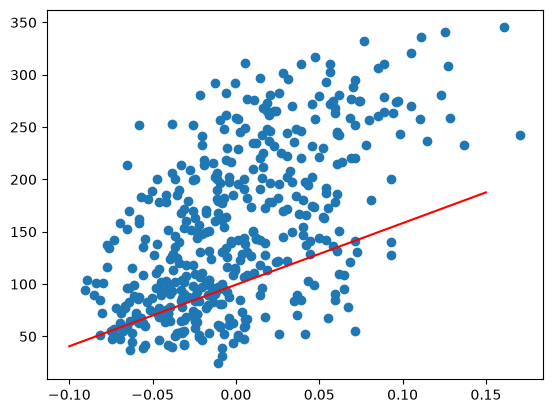

In [36]:
# 그래프로 확인해보자
plt.scatter(x,y)
pt1 = (-0.1, -0.1 * w + b)
pt2 = (0.15, 0.15 * w + b)
plt.plot(
   [pt1[0],pt2[0]],
   [pt1[1],pt2[1]],
   c='red'
)
plt.show()

#### Epoch로 반복한다

In [37]:
# Epoch를 통한 반복하기
w = b = 1
for _ in range(300):
   for x_i, y_i in zip(x,y):
      y_hat = x_i * w + b
      err = y_i - y_hat
      w_rate = x_i
      w = w + w_rate * err
      b = b + 1 * err
print(w,b)


913.5973364346786 123.39414383177173


> Y^ = 913.6 * X + 1234

In [39]:
# 모델로 예측해보기
x_new = 0.18
y_pred = x_new * w + b
y_pred

np.float64(287.8416643900139)

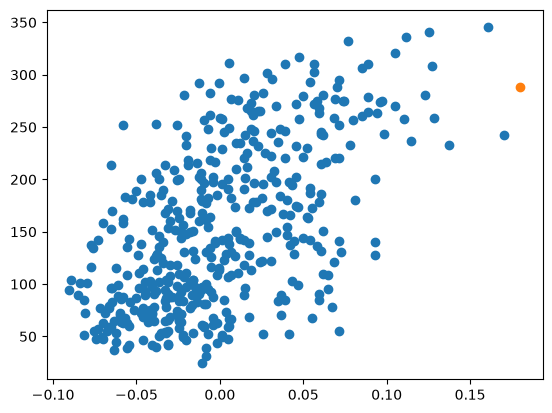

In [40]:
plt.scatter(x,y)
plt.scatter(x_new,y_pred)

plt.show()